In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from pathlib import Path
import urllib.request

def download_shakespeare_text():
    path = Path("datasets/shakespeare/shakespeare.txt")

    if not path.is_file():
        path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://homl.info/shakespeare"
        urllib.request.urlretrieve(url, path)
    return path.read_text()

shakespeare_text = download_shakespeare_text()

In [10]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from functools import partial
from torch.optim import Optimizer, Adam

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)


class TextData(Dataset):
    def __init__(self, encoded_text, window_length:int, stride:int = 32):
        self.window_length = window_length
        self.encoded_text = encoded_text
        self.stride = stride
        
    def __len__(self):
        return (len(self.encoded_text) - self.window_length - 1) // self.stride + 1
    
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("dataset index out of range")
        start = index * self.stride
        end = start + self.window_length
        window = self.encoded_text[start:end]
        target = self.encoded_text[start+1:end+1]
        return torch.tensor(window), torch.tensor(target)

tokenized_text = tokenizer(shakespeare_text)["input_ids"]
window_len = 128
dataset = TextData(tokenized_text, window_len)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True, pin_memory=True)
optimizer = Adam(model.parameters(), lr=1e-5)
num_epoch = 5

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


In [8]:
from typing import Callable
from torch import Tensor

def train(model:nn.Module, train_loader:DataLoader, optimizer:Optimizer, epoch_num:int = 5, 
          loss_fn:Callable[[torch.Tensor, torch.Tensor], torch.Tensor] = F.cross_entropy) -> list[list[float]]:
    model.train()
    loss_history:list[list[float]] = [[] for _ in range(epoch_num)]
    for epoch_idx in range(epoch_num):
        for X,y in train_loader:
            X:Tensor
            y:Tensor
            X,y = X.to(device), y.to(device)
            
            optimizer.zero_grad()
            y_pred:Tensor = model(X).logits
            loss = loss_fn(y_pred.permute(0,2,1), y)
            loss.backward()
            optimizer.step()
            loss_history[epoch_idx].append(loss.item())
    
    return loss_history

In [11]:
loss_history = train(model, train_loader, optimizer, epoch_num=5)

[3.6557742187471103, 3.390012881791953, 3.263472623536081, 3.160543423349207, 3.067481635917317]


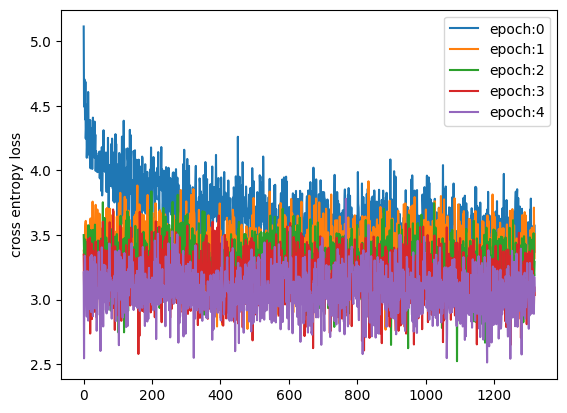

In [12]:
import matplotlib.pyplot as plt

avg_loss_per_epoch = [sum(epoch_loss)/len(epoch_loss) for epoch_loss in loss_history]
print(avg_loss_per_epoch)

for idx, loss_per_batch in enumerate(loss_history):
    plt.plot(loss_per_batch, label=f"epoch:{idx}")

plt.ylabel("cross entropy loss")
plt.legend()
plt.show()

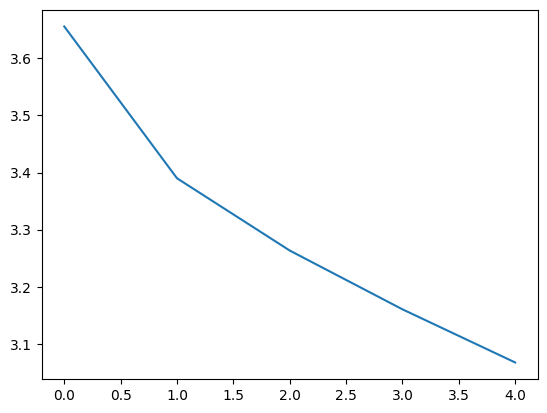

In [13]:
plt.plot(avg_loss_per_epoch)
plt.show()